# Experiment 1 — Financial factor models

Saved out-of-sample metrics, residual dependence and 1-additive Choquet weights for the linear equity factor models.

In [1]:
from IPython.display import Image, Markdown, display
from mwc_experiments.reporting import load_result_table, result_figure_path

## Factor data and model comparison

### Aggregate and asset-level performance
Start with the overall ranking, then check whether it is broad-based or driven by a few equities.

,RMSE mean,RMSE std,MAE mean,MAE std,OOS R2 mean,OOS R2 std,Correlation mean,Correlation std,parameter count mean,parameter count std,refit runtime seconds mean,refit runtime seconds std
model,,,,,,,,,,,,
Choquet 1-additive,0.022267,0.011224,0.016465,0.009064,-0.261653,0.708491,0.600190,0.179917,8.0,0.0,0.039534,0.006306
Choquet 2-additive,0.022063,0.010725,0.016330,0.008700,-0.234723,0.663943,0.598185,0.176239,29.0,0.0,0.066259,0.018164
Choquet 2-additive L1,0.022317,0.010863,0.016510,0.008763,-0.264318,0.672558,0.595789,0.179547,29.0,0.0,0.053868,0.037379
Elastic net,0.014017,0.004221,0.009265,0.003261,0.509820,0.156165,0.737156,0.109805,8.0,0.0,0.003226,0.000335
Explicit interactions,0.014653,0.004660,0.009856,0.003588,0.467198,0.174374,0.705998,0.131874,29.0,0.0,0.004753,0.000773
Gradient boosting,0.014198,0.004120,0.009372,0.003131,0.495949,0.157838,0.717780,0.124601,NaN,NaN,0.150891,0.037332
Lasso,0.014003,0.004199,0.009260,0.003249,0.510588,0.155850,0.737294,0.111256,8.0,0.0,0.004523,0.001120
Monotone linear,0.013852,0.003769,0.009154,0.002812,0.516711,0.152442,0.739556,0.112935,8.0,0.0,0.005291,0.001058
OLS,0.014012,0.004222,0.009298,0.003259,0.509757,0.157749,0.734532,0.114942,8.0,0.0,0.003638,0.000896


MSE      RMSE       MAE  Tail-weighted MAE  \
asset model                                                                    
AAPL  Choquet 1-additive     0.000377  0.019407  0.014345           0.015155   
      Choquet 2-additive     0.000366  0.019136  0.014228           0.015191   
      Choquet 2-additive L1  0.000371  0.019256  0.014324           0.015274   
      Elastic net            0.000243  0.015596  0.011024           0.011794   
      Explicit interactions  0.000259  0.016103  0.011437           0.012519   
...                               ...       ...       ...                ...   
XOM   Monotone linear        0.000120  0.010953  0.007121           0.009208   
      OLS                    0.000112  0.010574  0.006858           0.008752   
      OLS oriented           0.000112  0.010574  0.006858           0.008752   
      Random forest          0.000112  0.010595  0.006467           0.008375   
      Ridge                  0.000112  0.010574  0.006858           0.008752   

                               OOS R2  Correlation  validation RMSE  \
asset model                                                           
AAPL  Choquet 1-additive     0.031519     0.674213         0.010644   
      Choquet 2-additive     0.058402     0.675008         0.010922   
      Choquet 2-additive L1  0.046569     0.675340         0.010929   
      Elastic net            0.374572     0.693843         0.009639   
      Explicit interactions  0.333208     0.681384         0.009863   
...                               ...          ...              ...   
XOM   Monotone linear        0.714491     0.889862         0.005433   
      OLS                    0.733932     0.892556         0.005440   
      OLS oriented           0.733932     0.892556         0.005440   
      Random forest          0.732865     0.889173         0.005718   
      Ridge                  0.733929     0.892556         0.005440   

                             selection runtime seconds  refit runtime seconds  \
asset model                                                                     
AAPL  Choquet 1-additive                      0.086856               0.037816   
      Choquet 2-additive                      0.069419               0.062528   
      Choquet 2-additive L1                   0.288884               0.050384   
      Elastic net                             0.045157               0.003276   
      Explicit interactions                   0.023447               0.005247   
...                                                ...                    ...   
XOM   Monotone linear                         0.006460               0.003881   
      OLS                                     0.004253               0.003089   
      OLS oriented                            0.009737               0.004578   
      Random forest                           2.712344               0.403981   
      Ridge                                   0.028714               0.003248   

                             parameter count  
asset model                                   
AAPL  Choquet 1-additive                 8.0  
      Choquet 2-additive                29.0  
      Choquet 2-additive L1             29.0  
      Elastic net                        8.0  
      Explicit interactions             29.0  
...                                      ...  
XOM   Monotone linear                    8.0  
      OLS                                8.0  
      OLS oriented                       8.0  
      Random forest                      NaN  
      Ridge                              8.0  

[108 rows x 10 columns]

### In-sample descriptive fit
This table supports factor-risk interpretation; it is not used to select the forecasting model.

MSE      RMSE       MAE  Tail-weighted MAE  \
asset model                                                                    
AAPL  Choquet 1-additive     0.000100  0.009979  0.007258           0.008128   
      Choquet 2-additive     0.000099  0.009935  0.007205           0.008079   
      Choquet 2-additive L1  0.000099  0.009930  0.007208           0.008073   
      Elastic net            0.000086  0.009283  0.006619           0.007582   
      Explicit interactions  0.000084  0.009162  0.006576           0.007441   
...                               ...       ...       ...                ...   
XOM   Monotone linear        0.000038  0.006154  0.004500           0.005187   
      OLS                    0.000036  0.005997  0.004377           0.005003   
      OLS oriented           0.000036  0.005997  0.004377           0.005003   
      Random forest          0.000034  0.005865  0.004246           0.004923   
      Ridge                  0.000036  0.005997  0.004377           0.005003   

                             Correlation        R2  
asset model                                         
AAPL  Choquet 1-additive        0.771517  0.576902  
      Choquet 2-additive        0.772660  0.580640  
      Choquet 2-additive L1     0.773582  0.581004  
      Elastic net               0.796144  0.633845  
      Explicit interactions     0.802088  0.643345  
...                                  ...       ...  
XOM   Monotone linear           0.851459  0.724983  
      OLS                       0.859553  0.738831  
      OLS oriented              0.859553  0.738831  
      Random forest             0.866602  0.750192  
      Ridge                     0.859553  0.738831  

[108 rows x 6 columns]

...

MSE      RMSE       MAE  Tail-weighted MAE  \
asset model                                                                 
AAPL  Choquet 1-additive  0.000377  0.019407  0.014345           0.015155   
      Choquet 2-additive  0.000366  0.019136  0.014228           0.015191   
      Monotone linear     0.000232  0.015245  0.010840           0.011696   
      OLS                 0.000244  0.015605  0.011031           0.011801   
      OLS oriented        0.000244  0.015605  0.011031           0.011801   
AMZN  Choquet 1-additive  0.000681  0.026104  0.020226           0.021633   
      Choquet 2-additive  0.000673  0.025935  0.020110           0.021388   
      Monotone linear     0.000250  0.015811  0.011805           0.012587   
      OLS                 0.000260  0.016129  0.012193           0.012903   
      OLS oriented        0.000260  0.016129  0.012193           0.012903   
JPM   Choquet 1-additive  0.000191  0.013838  0.009423           0.010881   
      Choquet 2-additive  0.000199  0.014102  0.009565           0.011243   
      Monotone linear     0.000118  0.010858  0.006361           0.007861   
      OLS                 0.000112  0.010592  0.005983           0.007482   
      OLS oriented        0.000112  0.010592  0.005983           0.007482   
KO    Choquet 1-additive  0.000233  0.015277  0.011429           0.012533   
      Choquet 2-additive  0.000231  0.015192  0.011385           0.012490   
      Monotone linear     0.000073  0.008546  0.005524           0.006880   
      OLS                 0.000072  0.008505  0.005540           0.006827   
      OLS oriented        0.000072  0.008505  0.005540           0.006827   
MSFT  Choquet 1-additive  0.000421  0.020517  0.015173           0.016210   
      Choquet 2-additive  0.000408  0.020201  0.014866           0.015810   
      Monotone linear     0.000166  0.012874  0.008186           0.009042   
      OLS                 0.000160  0.012639  0.008050           0.008941   
      OLS oriented        0.000160  0.012639  0.008050           0.008941   
NVDA  Choquet 1-additive  0.002479  0.049787  0.038590           0.041671   
      Choquet 2-additive  0.002334  0.048309  0.037541           0.040074   
      Monotone linear     0.000392  0.019798  0.013861           0.015293   
      OLS                 0.000462  0.021485  0.015312           0.016753   
      OLS oriented        0.000462  0.021485  0.015312           0.016753   
UNH   Choquet 1-additive  0.000430  0.020740  0.013511           0.016986   
      Choquet 2-additive  0.000442  0.021016  0.013781           0.017674   
      Monotone linear     0.000346  0.018598  0.010945           0.014819   
      OLS                 0.000343  0.018510  0.010903           0.014733   
      OLS oriented        0.000343  0.018510  0.010903           0.014733   
WMT   Choquet 1-additive  0.000510  0.022574  0.016997           0.018743   
      Choquet 2-additive  0.000494  0.022233  0.016776           0.018662   
      Monotone linear     0.000144  0.011982  0.007743           0.009799   
      OLS                 0.000146  0.012071  0.007816           0.009856   
      OLS oriented        0.000146  0.012071  0.007816           0.009856   
XOM   Choquet 1-additive  0.000148  0.012159  0.008495           0.010392   
      Choquet 2-additive  0.000155  0.012442  0.008722           0.010712   
      Monotone linear     0.000120  0.010953  0.007121           0.009208   
      OLS                 0.000112  0.010574  0.006858           0.008752   
      OLS oriented        0.000112  0.010574  0.006858           0.008752   

                            OOS R2  Correlation  validation RMSE  \
asset model                                                        
AAPL  Choquet 1-additive  0.031519     0.674213         0.010644   
      Choquet 2-additive  0.058402     0.675008         0.010922   
      Monotone linear     0.402393     0.710921         0.010261   
      OLS                 0.373795     0.693649         0.009638   
   

### Validation-regime robustness
Assess whether including the 2020–2021 stress episode changes model selection or subsequent test performance.

validation observations  \
asset regime              model                                            
AAPL  excluding 2020-2021 Choquet 1-additive                         503   
                          Choquet 2-additive                         503   
                          Choquet 2-additive L1                      503   
                          Elastic net                                503   
                          Explicit interactions                      503   
...                                                                  ...   
XOM   including stress    Monotone linear                           1008   
                          OLS                                       1008   
                          OLS oriented                              1008   
                          Random forest                             1008   
                          Ridge                                     1008   

                                                 validation folds  \
asset regime              model                                     
AAPL  excluding 2020-2021 Choquet 1-additive                    4   
                          Choquet 2-additive                    4   
                          Choquet 2-additive L1                 4   
                          Elastic net                           4   
                          Explicit interactions                 4   
...                                                           ...   
XOM   including stress    Monotone linear                       4   
                          OLS                                   4   
                          OLS oriented                          4   
                          Random forest                         4   
                          Ridge                                 4   

                                                 validation RMSE  \
asset regime              model                                    
AAPL  excluding 2020-2021 Choquet 1-additive            0.010561   
                          Choquet 2-additive            0.010748   
                          Choquet 2-additive L1         0.010749   
                          Elastic net                   0.009640   
                          Explicit interactions         0.009967   
...                                                          ...   
XOM   including stress    Monotone linear               0.010960   
                          OLS                           0.010845   
                          OLS oriented                  0.010845   
                          Random forest                 0.010623   
                          Ridge                         0.010845   

                                                                                   best parameters  \
asset regime              model                                                                      
AAPL  excluding 2020-2021 Choquet 1-additive                                                    {}   
                          Choquet 2-additive                                                    {}   
                          Choquet 2-additive L1  {'regressor__regressor__penalty': L1Penalty(we...   
                          Elastic net            {'regressor__alpha': 1e-05, 'regressor__l1_rat...   
                          Explicit interactions                  {'regressor__ridge__alpha': 10.0}   
...                                                                                            ...   
XOM   including stress    Monotone linear                                                       {}   
                          OLS                                                                   {}   
                          OLS oriented                                                          {}   
                          Random forest          {'regressor__max_depth': 6, 'regressor__min_sa...   
                          Ridge                      

validation-selected model  selected validation RMSE  \
asset regime                                                                    
AAPL  excluding 2020-2021                       OLS                  0.009640   
      including stress                        Lasso                  0.011550   
AMZN  excluding 2020-2021               Elastic net                  0.008293   
      including stress                  Elastic net                  0.010747   
JPM   excluding 2020-2021                       OLS                  0.004739   
      including stress                Random forest                  0.009877   
KO    excluding 2020-2021                     Lasso                  0.007098   
      including stress                        Ridge                  0.009671   
MSFT  excluding 2020-2021             Random forest                  0.006943   
      including stress                Random forest                  0.009359   
NVDA  excluding 2020-2021                     Ridge                  0.020222   
      including stress                        Lasso                  0.020125   
UNH   excluding 2020-2021           Monotone linear                  0.011238   
      including stress              Monotone linear                  0.014451   
WMT   excluding 2020-2021               Elastic net                  0.009959   
      including stress                  Elastic net                  0.011486   
XOM   excluding 2020-2021               Elastic net                  0.006284   
      including stress                Random forest                  0.010623   

                           selected model test RMSE        best test model  \
asset regime                                                                 
AAPL  excluding 2020-2021                  0.016145      Gradient boosting   
      including stress                     0.015757      Gradient boosting   
AMZN  excluding 2020-2021                  0.014831      Gradient boosting   
      including stress                     0.014366                  Lasso   
JPM   excluding 2020-2021                  0.008312                    OLS   
      including stress                     0.008411                    OLS   
KO    excluding 2020-2021                  0.007005          Random forest   
      including stress                     0.007080        Monotone linear   
MSFT  excluding 2020-2021                  0.013459  Explicit interactions   
      including stress                     0.013686  Explicit interactions   
NVDA  excluding 2020-2021                  0.019841        Monotone linear   
      including stress                     0.019801        Monotone linear   
UNH   excluding 2020-2021                  0.019118            Elastic net   
      including stress                     0.019118                  Lasso   
WMT   excluding 2020-2021                  0.011408                    OLS   
      including stress                     0.011460                    OLS   
XOM   excluding 2020-2021                  0.007050                  Lasso   
      including stress                     0.007154                  Lasso   

                           best test RMSE  selection regret  
asset regime                                                 
AAPL  excluding 2020-2021        0.014679          0.001466  
      including stress           0.014679          0.001078  
AMZN  excluding 2020-2021        0.014354          0.000476  
      including stress           0.014251          0.000115  
JPM   excluding 2020-2021        0.008312          0.000000  
      including stress           0.008312          0.000100  
KO    excluding 2020-2021        0.006910          0.000095  
      including stress           0.006999          0.000081  
MSFT  excluding 2020-2021        0.013105          0.000353  
      including stress           0.013105          0.000581  
NVDA  excluding 2020-2021        0.018399          0.001442  
      including stress           0.018

### Visual overview
Relate factor dependence to average and asset-specific RMSE rankings.

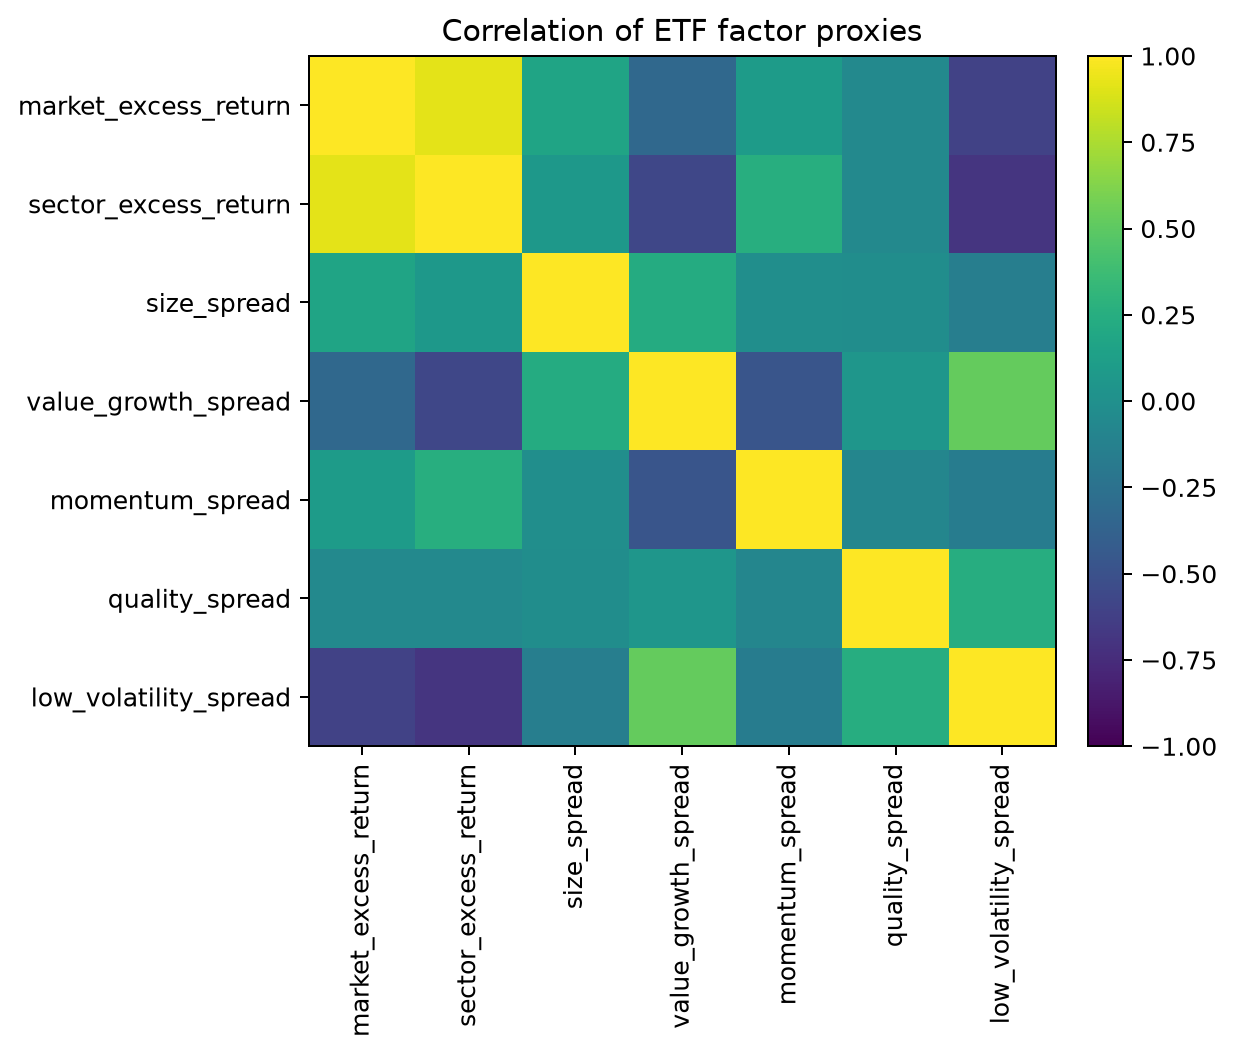

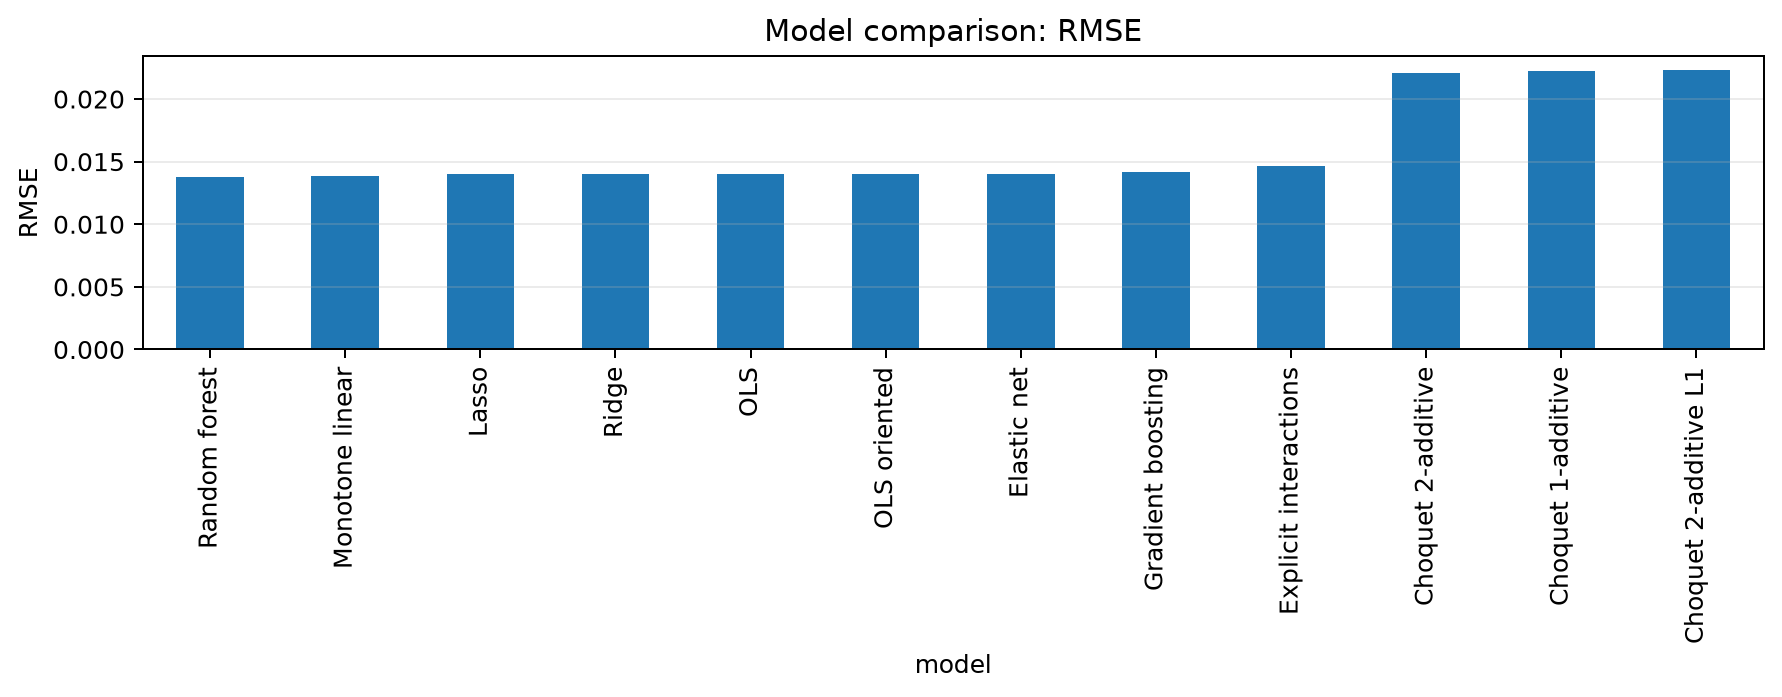

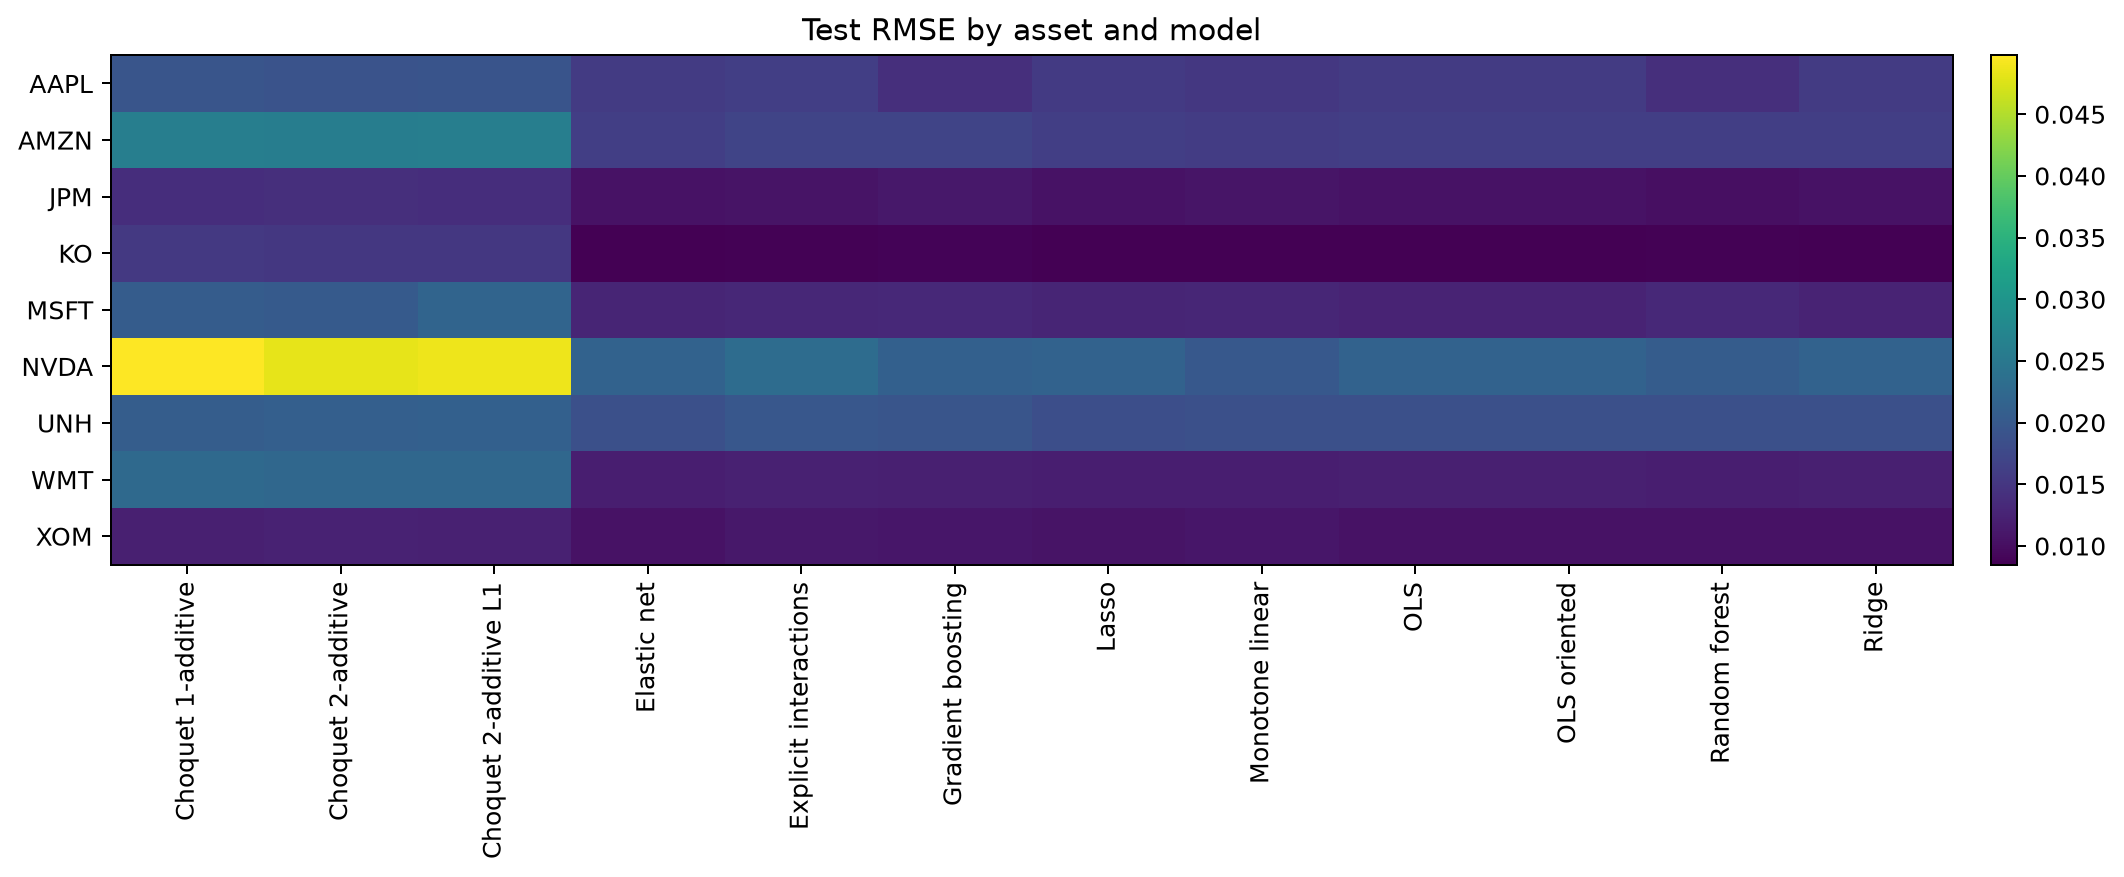

In [2]:
display(Markdown("### Aggregate and asset-level performance\nStart with the overall ranking, then check whether it is broad-based or driven by a few equities."))
display(load_result_table("experiment_1_aggregate_metrics.csv", index_col=0))
display(load_result_table("experiment_1_asset_model_metrics.csv", index_col=[0, 1]))
display(Markdown("### In-sample descriptive fit\nThis table supports factor-risk interpretation; it is not used to select the forecasting model."))
display(load_result_table("experiment_1_in_sample_asset_model_metrics.csv", index_col=[0, 1]))
display(Markdown("### Linear Choquet benchmark and orientation controls\nConfirm the 1-additive specification and check whether orientation alone explains performance differences."))
display(load_result_table("experiment_1_validation_selected_choquet.csv", index_col=0))
display(load_result_table("experiment_1_orientation_ablation.csv", index_col=[0, 1]))
display(Markdown("### Validation-regime robustness\nAssess whether including the 2020–2021 stress episode changes model selection or subsequent test performance."))
display(load_result_table("experiment_1_validation_stress_comparison.csv", index_col=[0, 1, 2]))
display(load_result_table("experiment_1_validation_stress_selection_summary.csv", index_col=[0, 1]))
display(Markdown("### Visual overview\nRelate factor dependence to average and asset-specific RMSE rankings."))
display(Image(filename=result_figure_path("experiment_1_factor_correlation.png")))
display(Image(filename=result_figure_path("experiment_1_mean_rmse.png")))
display(Image(filename=result_figure_path("experiment_1_asset_rmse.png")))

## In-sample risk diagnostics, residual covariance and representative forecasts

### Residual dependence
Compare descriptive in-sample covariance with held-out residual dependence to see what common risk remains unexplained.

,trace,Frobenius norm,mean absolute off-diagonal
model,,,
Gradient boosting,0.000721,0.000334,0.000003
Random forest,0.000787,0.000353,0.000003
Explicit interactions,0.000915,0.000423,0.000004
OLS,0.000946,0.000437,0.000004
OLS oriented,0.000946,0.000437,0.000004
Ridge,0.000946,0.000437,0.000004
Lasso,0.000948,0.000437,0.000004
Elastic net,0.000950,0.000437,0.000004
Monotone linear,0.000970,0.000448,0.000004


,trace,Frobenius norm,mean absolute off-diagonal
model,,,
Random forest,0.001840,0.000725,0.000019
Monotone linear,0.001840,0.000731,0.000024
Lasso,0.001906,0.000766,0.000022
Ridge,0.001909,0.000768,0.000021
OLS,0.001910,0.000768,0.000021
OLS oriented,0.001910,0.000768,0.000021
Elastic net,0.001911,0.000769,0.000022
Gradient boosting,0.001944,0.000775,0.000023
Explicit interactions,0.002101,0.000852,0.000022


### Common stress scenario and estimation robustness
All models face the same empirical extremes; the tables separate conditional performance from coefficient sensitivity.

observations  feature-extreme observations  \
asset sample                                                   
AAPL  estimation          1509                            74   
      test                1652                           506   
AMZN  estimation          1509                            74   
      test                1652                           514   
JPM   estimation          1509                            77   
      test                1652                           514   
KO    estimation          1509                            79   
      test                1652                           512   
MSFT  estimation          1509                            74   
      test                1652                           506   
NVDA  estimation          1509                            74   
      test                1652                           506   
UNH   estimation          1509                            77   
      test                1652                           509   
WMT   estimation          1509                            79   
      test                1652                           512   
XOM   estimation          1509                            85   
      test                1652                           522   

                  loss-extreme observations  stress observations  stress rate  \
asset sample                                                                    
AAPL  estimation                         16                   84     0.055666   
      test                               28                  512     0.309927   
AMZN  estimation                         16                   83     0.055003   
      test                               21                  520     0.314770   
JPM   estimation                         16                   84     0.055666   
      test                               44                  527     0.319007   
KO    estimation                         16                   86     0.056991   
      test                               39                  521     0.315375   
MSFT  estimation                         16                   84     0.055666   
      test                               42                  511     0.309322   
NVDA  estimation                         16                   83     0.055003   
      test                               37                  509     0.308111   
UNH   estimation                         16                   89     0.058979   
      test                               48                  529     0.320218   
WMT   estimation                         16                   91     0.060305   
      test                               26                  523     0.316586   
XOM   estimation                         16                   93     0.061630   
      test                               76                  545     0.329903   

                  loss threshold  
asset sample                      
AAPL  estimation        0.044322  
      test              0.044322  
AMZN  estimation        0.055264  
      test              0.055264  
JPM   estimation        0.036959  
      test              0.036959  
KO    estimation        0.025462  
      test              0.025462  
MSFT  estimation        0.038446  
      test              0.038446  
NVDA  estimation        0.068638  
      test              0.068638  
UNH   estimation        0.034308  
      test              0.034308  
WMT   estimation        0.031271  
      test              0.031271  
XOM   estimation        0.033083  
      test              0.033083

stress observations       MSE      RMSE  \
asset model                                                            
AAPL  Random forest                          512  0.000386  0.019659   
      Gradient boosting                      512  0.000395  0.019876   
      Monotone linear                        512  0.000460  0.021438   
      Lasso                                  512  0.000482  0.021944   
      Elastic net                            512  0.000483  0.021981   
...                                          ...       ...       ...   
XOM   Monotone linear                        545  0.000252  0.015888   
      Explicit interactions                  545  0.000254  0.015930   
      Choquet 1-additive                     545  0.000295  0.017172   
      Choquet 2-additive L1                  545  0.000304  0.017430   
      Choquet 2-additive                     545  0.000309  0.017578   

                                  MAE  Tail-weighted MAE    OOS R2  \
asset model                                                          
AAPL  Random forest          0.013645           0.014976  0.536050   
      Gradient boosting      0.013708           0.015520  0.525778   
      Monotone linear        0.015926           0.017019  0.448276   
      Lasso                  0.015955           0.016830  0.421965   
      Elastic net            0.015985           0.016856  0.419991   
...                               ...                ...       ...   
XOM   Monotone linear        0.010297           0.014085  0.693767   
      Explicit interactions  0.010340           0.013666  0.692161   
      Choquet 1-additive     0.012116           0.015335  0.642252   
      Choquet 2-additive L1  0.012397           0.015603  0.631441   
      Choquet 2-additive     0.012490           0.015795  0.625172   

                             Correlation  
asset model                               
AAPL  Random forest             0.740323  
      Gradient boosting         0.728069  
      Monotone linear           0.725035  
      Lasso                     0.708356  
      Elastic net               0.707802  
...                                  ...  
XOM   Monotone linear           0.895345  
      Explicit interactions     0.859423  
      Choquet 1-additive        0.827280  
      Choquet 2-additive L1     0.820634  
      Choquet 2-additive        0.815277  

[108 rows x 7 columns]

fit observations  \
asset model                                     
AAPL  OLS                                1509   
      Ridge                              1509   
      Lasso                              1509   
      Monotone linear                    1509   
      Gradient boosting                  1509   
...                                       ...   
XOM   Monotone linear                    1509   
      Gradient boosting                  1509   
      Choquet 1-additive                 1509   
      Choquet 2-additive                 1509   
      Choquet 2-additive L1              1509   

                             extreme fit observations removed  \
asset model                                                     
AAPL  OLS                                                  84   
      Ridge                                                84   
      Lasso                                                84   
      Monotone linear                                      84   
      Gradient boosting                                    84   
...                                                       ...   
XOM   Monotone linear                                      93   
      Gradient boosting                                    93   
      Choquet 1-additive                                   93   
      Choquet 2-additive                                   93   
      Choquet 2-additive L1                                93   

                             extreme fit rate  test observations  \
asset model                                                        
AAPL  OLS                            0.055666               1652   
      Ridge                          0.055666               1652   
      Lasso                          0.055666               1652   
      Monotone linear                0.055666               1652   
      Gradient boosting              0.055666               1652   
...                                       ...                ...   
XOM   Monotone linear                0.061630               1652   
      Gradient boosting              0.061630               1652   
      Choquet 1-additive             0.061630               1652   
      Choquet 2-additive             0.061630               1652   
      Choquet 2-additive L1          0.061630               1652   

                             stress test observations  full-fit test RMSE  \
asset model                                                                 
AAPL  OLS                                         512            0.015605   
      Ridge                                       512            0.015605   
      Lasso                                       512            0.015567   
      Monotone linear                             512            0.015245   
      Gradient boosting                           512            0.014135   
...                                               ...                 ...   
XOM   Monotone linear                             545            0.010953   
      Gradient boosting                           545            0.010948   
      Choquet 1-additive                          545            0.012159   
      Choquet 2-additive                          545            0.012442   
      Choquet 2-additive L1                       545            0.012347   

                             reduced-fit test RMSE  test RMSE change  \
asset model                                                            
AAPL  OLS                                 0.015558         -0.000048   
      Ridge                               0.015557         -0.000048   
      Lasso                               0.015522         -0.000046   
      Monotone linear                     0.015100         -0.000145   
      Gradient boosting                   0.014787          0.000653   
...                                            ...               ...   
XOM   Monotone linear                     0.011915          0.000962   
      Grad

### Clipping audit
Quantify how often predictors reach training-estimated bounds before attributing robustness to a model family.

raw minimum  lower clipping bound  \
asset sample     feature                                                    
AAPL  estimation market_excess_return     -0.043021             -0.030589   
                 sector_excess_return     -0.051880             -0.038937   
                 size_spread              -0.017633             -0.013982   
                 value_growth_spread      -0.016636             -0.011964   
                 momentum_spread          -0.017229             -0.014094   
...                                             ...                   ...   
XOM   test       size_spread              -0.029405             -0.013982   
                 value_growth_spread      -0.034833             -0.011964   
                 momentum_spread          -0.042563             -0.014094   
                 quality_spread           -0.016625             -0.004581   
                 low_volatility_spread    -0.049190             -0.010513   

                                        raw maximum  upper clipping bound  \
asset sample     feature                                                    
AAPL  estimation market_excess_return      0.049194              0.023615   
                 sector_excess_return      0.058546              0.031223   
                 size_spread               0.025020              0.016718   
                 value_growth_spread       0.023000              0.015553   
                 momentum_spread           0.015703              0.010384   
...                                             ...                   ...   
XOM   test       size_spread               0.043973              0.016718   
                 value_growth_spread       0.046915              0.015553   
                 momentum_spread           0.037212              0.010384   
                 quality_spread            0.014470              0.004655   
                 low_volatility_spread     0.038737              0.009934   

                                        below-bound observations  \
asset sample     feature                                           
AAPL  estimation market_excess_return                          8   
                 sector_excess_return                          8   
                 size_spread                                   8   
                 value_growth_spread                           8   
                 momentum_spread                               8   
...                                                          ...   
XOM   test       size_spread                                  77   
                 value_growth_spread                         143   
                 momentum_spread                              62   
                 quality_spread                               42   
                 low_volatility_spread                        57   

                                        above-bound observations  \
asset sample     feature                                           
AAPL  estimation market_excess_return                          8   
                 sector_excess_return                          8   
                 size_spread                                   8   
                 value_growth_spread                           8   
                 momentum_spread                               8   
...                                                          ...   
XOM   test       size_spread                                  45   
                 value_growth_spread                          75   
                 momentum_spread                             113   
                 quality_spread                               45   
                 low_volatility_spread                        76   

                                        clipped observations  clipped rate  
asset sample     feature                                                    
AAPL  estimation market_excess_return                     16      0.010603  
                 sector_excess_retu

### Residual covariance maps
Contrast the dependence left by OLS and Choquet 2-additive fits.

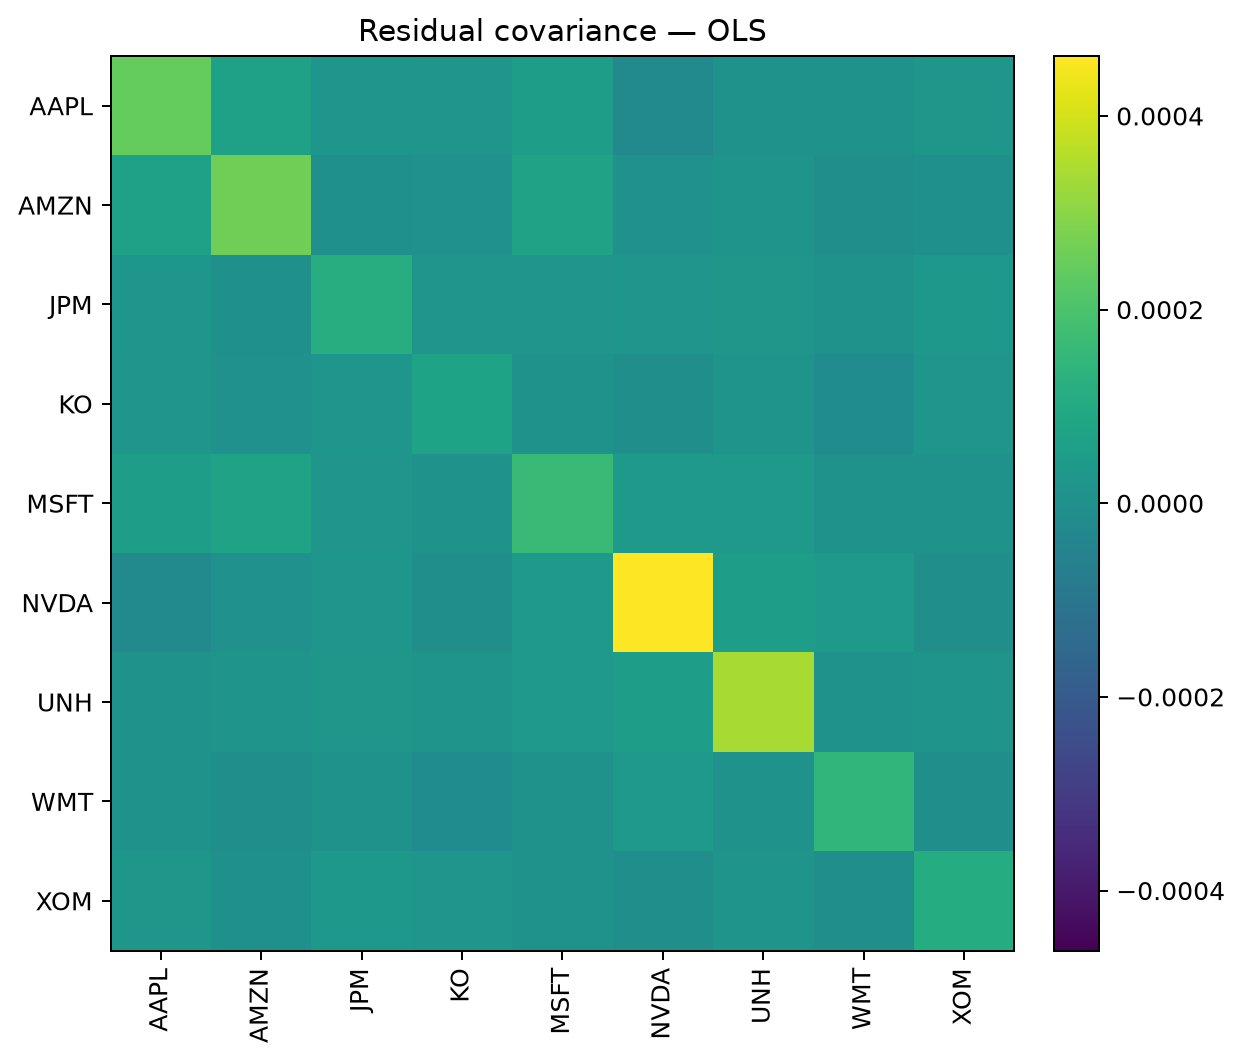

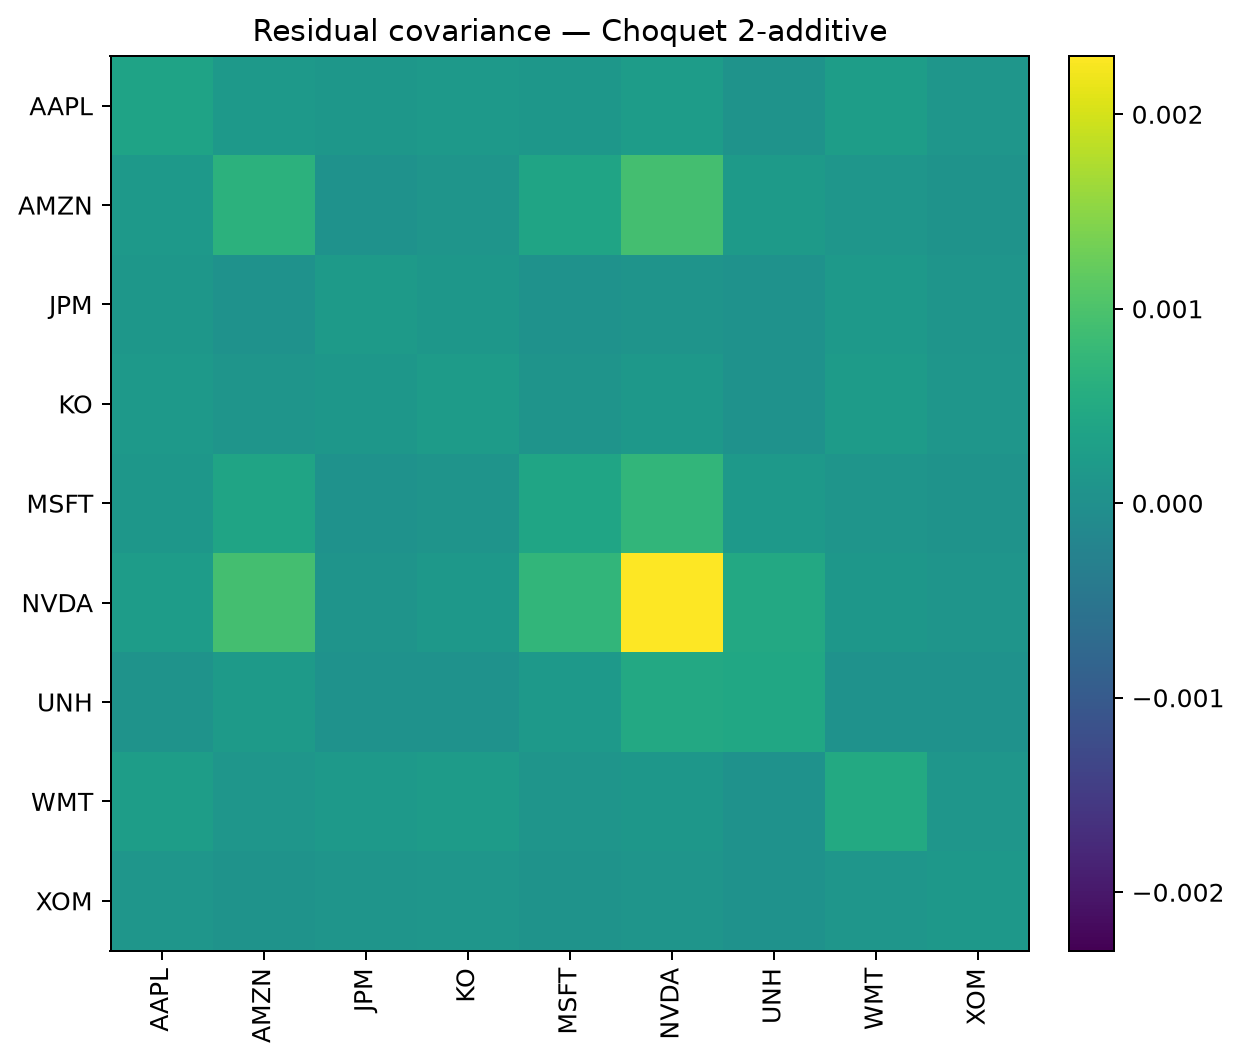

### Representative forecast paths
Inspect whether aggregate metrics reflect persistent tracking quality or isolated episodes.

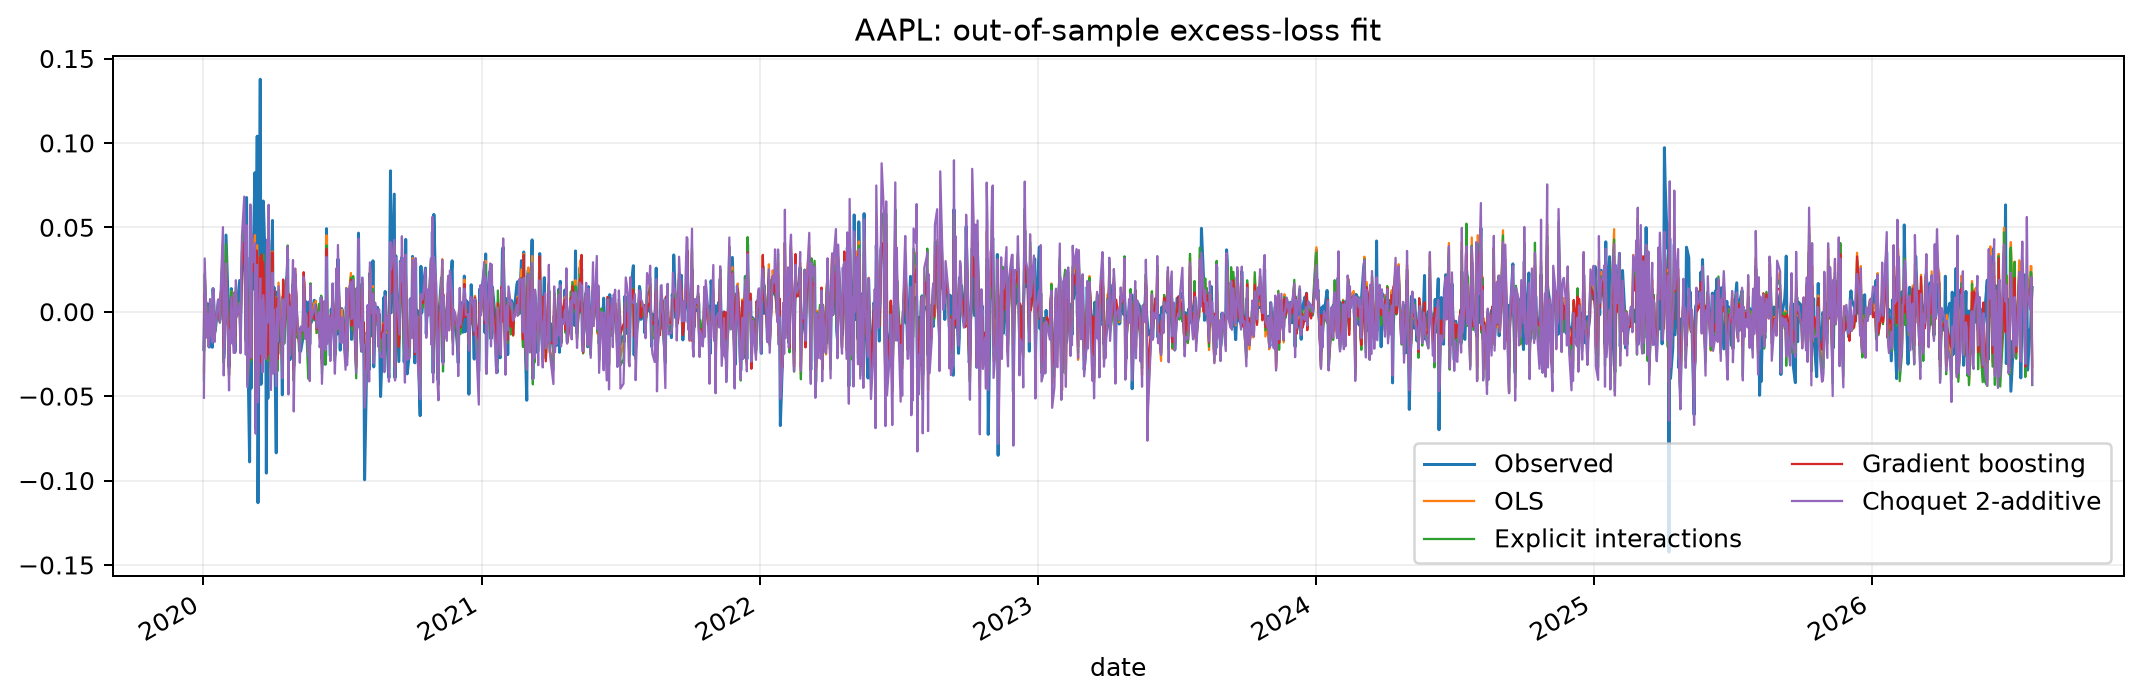

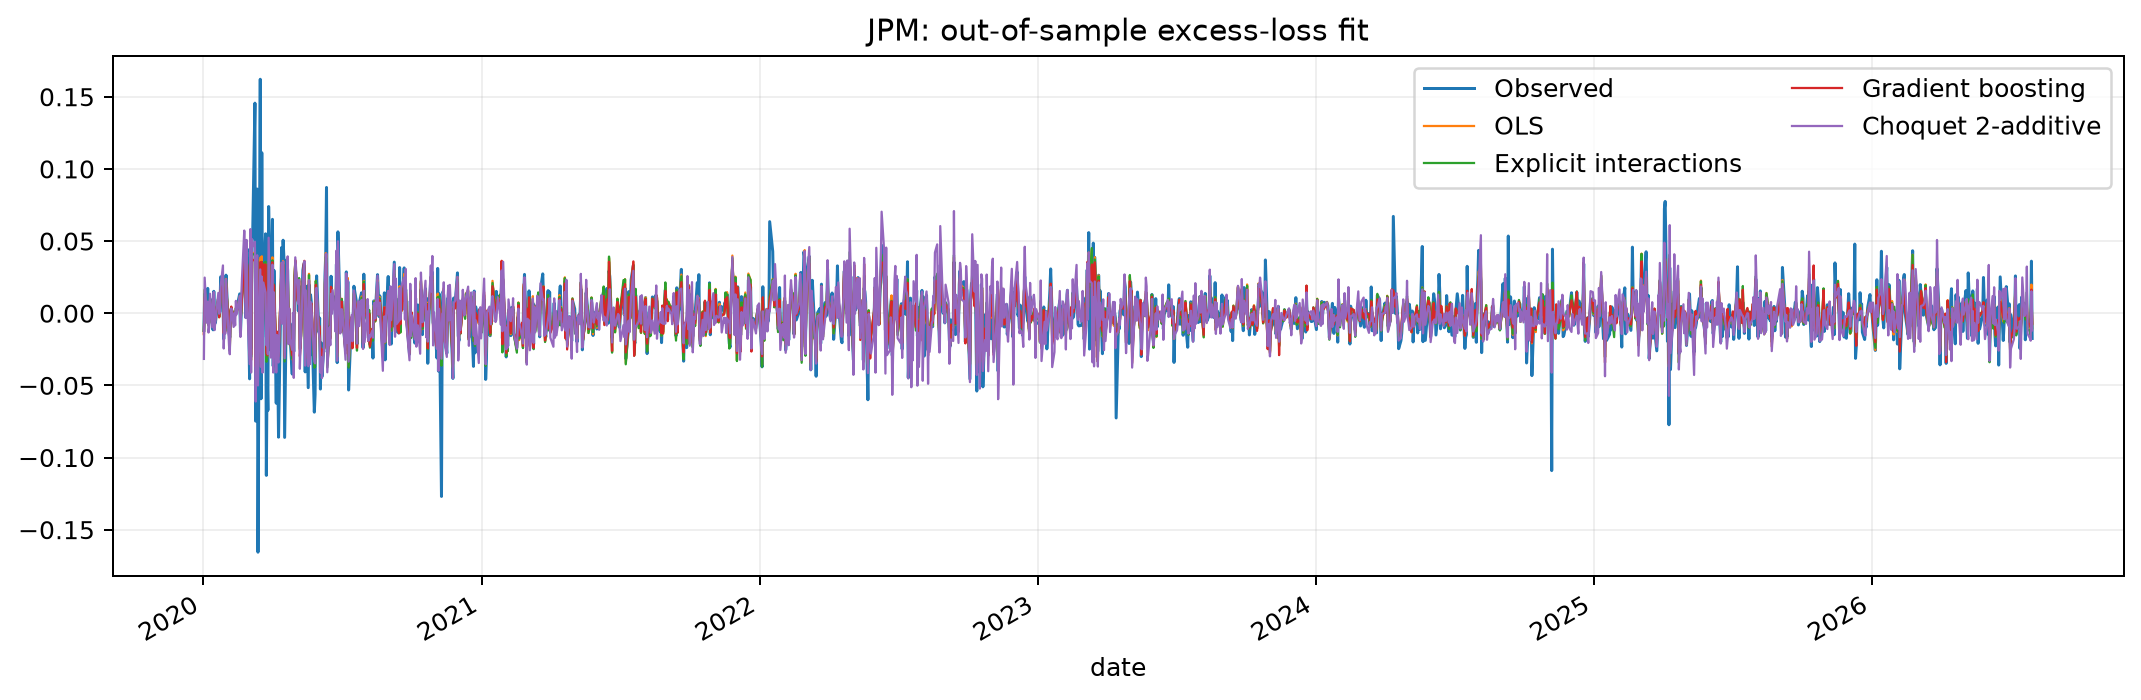

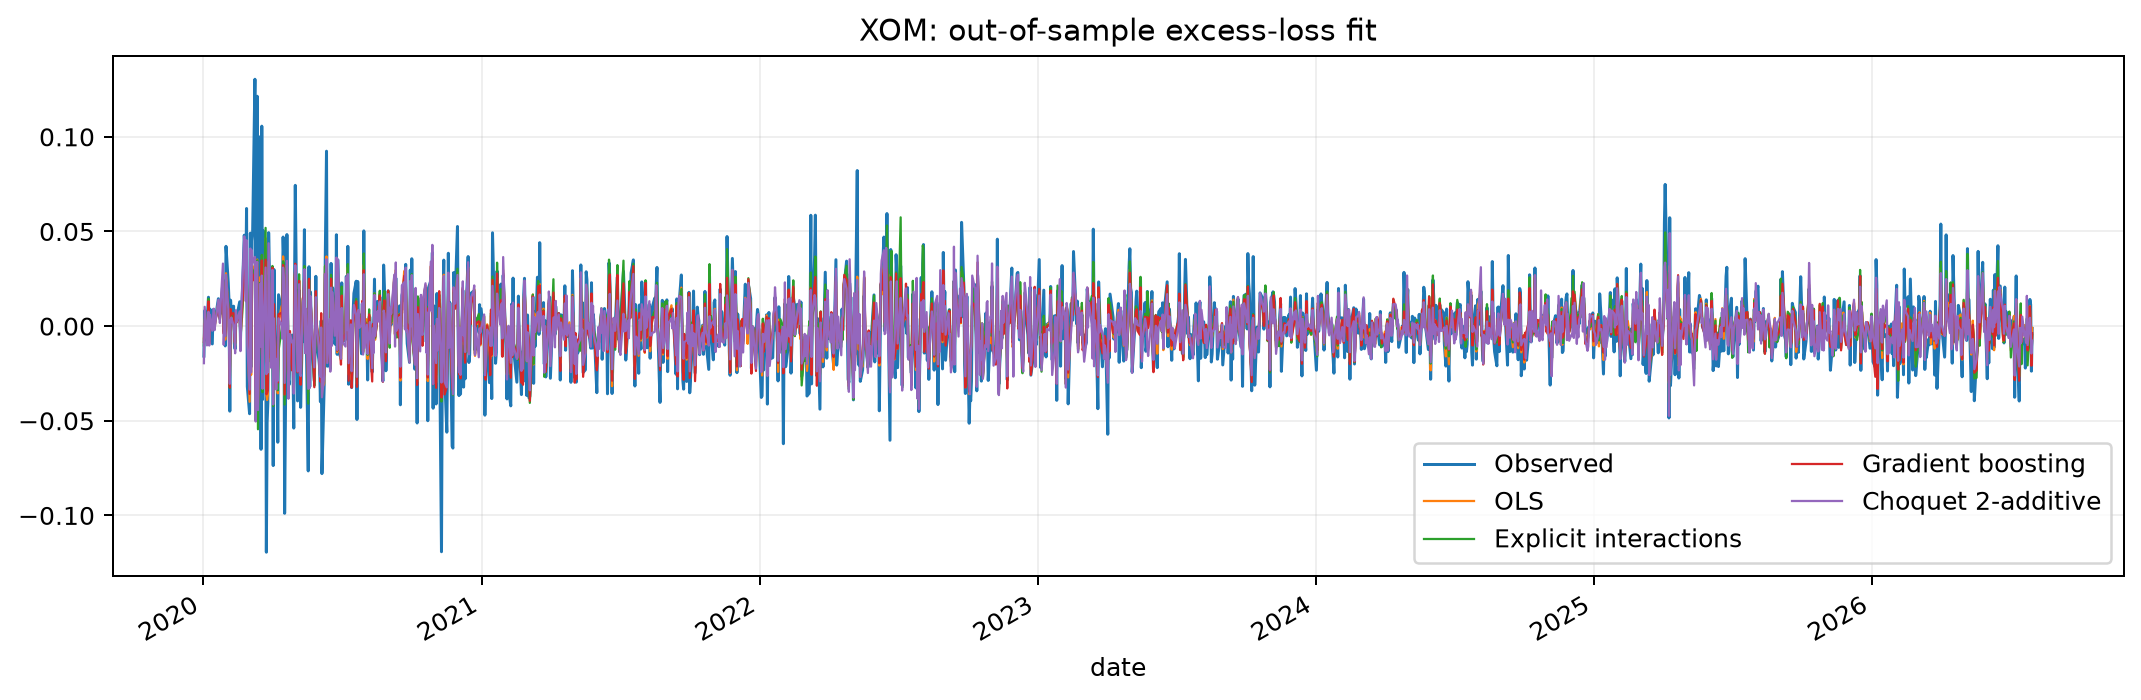

In [3]:
display(Markdown("### Residual dependence\nCompare descriptive in-sample covariance with held-out residual dependence to see what common risk remains unexplained."))
display(load_result_table("experiment_1_in_sample_residual_covariance_summary.csv", index_col=0))
display(load_result_table("experiment_1_residual_covariance_summary.csv", index_col=0))
display(Markdown("### Common stress scenario and estimation robustness\nAll models face the same empirical extremes; the tables separate conditional performance from coefficient sensitivity."))
display(load_result_table("experiment_1_empirical_stress_audit.csv", index_col=[0, 1]))
display(load_result_table("experiment_1_empirical_stress_metrics.csv", index_col=[0, 1]))
display(load_result_table("experiment_1_extreme_estimation_robustness.csv", index_col=[0, 1]))
display(Markdown("### Clipping audit\nQuantify how often predictors reach training-estimated bounds before attributing robustness to a model family."))
display(load_result_table("experiment_1_clipping_audit.csv", index_col=[0, 1, 2]))
display(Markdown("### Residual covariance maps\nContrast the dependence left by OLS and the linear Choquet 1-additive fit."))
display(Image(filename=result_figure_path("experiment_1_residual_covariance_ols.png")))
display(Image(filename=result_figure_path("experiment_1_residual_covariance_choquet_1_additive.png")))
display(Markdown("### Representative forecast paths\nInspect whether aggregate metrics reflect persistent tracking quality or isolated episodes."))
display(Image(filename=result_figure_path("experiment_1_predictions_aapl.png")))
display(Image(filename=result_figure_path("experiment_1_predictions_jpm.png")))
display(Image(filename=result_figure_path("experiment_1_predictions_xom.png")))

## Factor weights and stability

### Feature importance and leading interactions
Use Shapley indices for marginal importance and the interaction table for the strongest pairwise departures from additivity.

,sector_excess_return,value_growth_spread,momentum_spread,size_spread,low_volatility_spread,market_excess_return,quality_spread
AAPL,0.342371,0.239029,0.238695,0.062532,5.352217e-02,0.048952,1.489757e-02
AMZN,0.256407,0.171742,0.127689,0.133073,1.646915e-01,0.028628,1.177695e-01
JPM,0.519739,0.143401,0.184631,0.065934,3.088617e-02,0.011870,4.353968e-02
KO,0.336255,0.244014,0.265790,0.078480,-7.300794e-19,0.012241,6.322000e-02
MSFT,0.153077,0.149198,0.095690,0.159828,1.015261e-01,0.242419,9.826146e-02
NVDA,0.021268,0.095756,0.210737,0.158903,2.152392e-01,0.182468,1.156284e-01
UNH,0.393058,0.006862,0.142484,0.131091,6.610284e-02,0.086982,1.734205e-01
WMT,0.252671,0.260023,0.281755,0.062242,3.841937e-02,0.030824,7.406534e-02
XOM,0.492619,0.086914,0.163111,0.108169,2.277997e-19,0.149187,5.335162e-18


,first,second,interaction,interpretation
0,sector_excess_return,size_spread,0.064699,complementary
1,sector_excess_return,momentum_spread,0.061860,complementary
2,sector_excess_return,value_growth_spread,0.047855,complementary
3,market_excess_return,low_volatility_spread,-0.035396,redundant
4,market_excess_return,momentum_spread,-0.030460,redundant
5,market_excess_return,value_growth_spread,-0.027440,redundant
6,value_growth_spread,low_volatility_spread,-0.026433,redundant
7,value_growth_spread,momentum_spread,0.025873,complementary
8,sector_excess_return,low_volatility_spread,0.024772,complementary
9,quality_spread,low_volatility_spread,-0.013592,redundant


### Stability and inference for AAPL
Check whether importance estimates persist across expanding samples and whether HAC comparisons support performance differences.

,low_volatility_spread,market_excess_return,momentum_spread,quality_spread,sector_excess_return,size_spread,value_growth_spread
2018-12-31,0.053895,0.048121,0.223258,0.007220,0.354353,0.045115,0.268038
2020-12-31,0.015528,0.177453,0.188001,0.042925,0.287414,0.068889,0.219790
2022-12-30,0.025423,0.162611,0.151465,0.102968,0.278811,0.093733,0.184989
2024-12-31,0.008411,0.197011,0.160625,0.114093,0.227819,0.094450,0.197591
2026-07-30,0.005364,0.215719,0.253363,0.096107,0.168018,0.088781,0.172648


,reference,mean loss difference,standard error,lower 95%,upper 95%,favors model
model,,,,,,
Random forest,Choquet 2-additive,-0.000169,1.905878e-05,-0.000206,-0.000131,True
Gradient boosting,Choquet 2-additive,-0.000166,1.733402e-05,-0.000200,-0.000132,True
Monotone linear,Choquet 2-additive,-0.000134,1.214921e-05,-0.000158,-0.000110,True
Lasso,Choquet 2-additive,-0.000124,1.427335e-05,-0.000152,-0.000096,True
Elastic net,Choquet 2-additive,-0.000123,1.426802e-05,-0.000151,-0.000095,True
Ridge,Choquet 2-additive,-0.000123,1.426670e-05,-0.000151,-0.000095,True
OLS,Choquet 2-additive,-0.000123,1.426728e-05,-0.000151,-0.000095,True
OLS oriented,Choquet 2-additive,-0.000123,1.426728e-05,-0.000151,-0.000095,True
Explicit interactions,Choquet 2-additive,-0.000107,1.408901e-05,-0.000134,-0.000079,True


### Capacity visualizations
The figures summarize average importance, cross-asset heterogeneity, interactions and temporal stability.

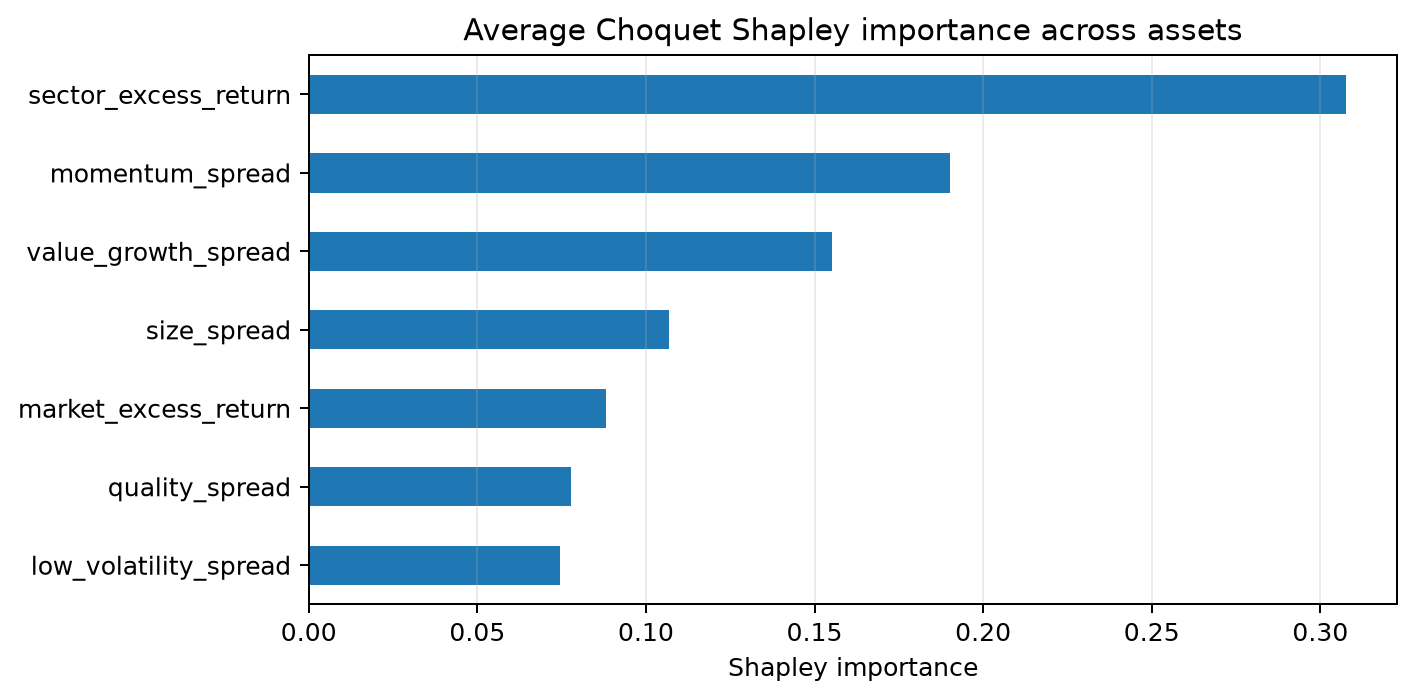

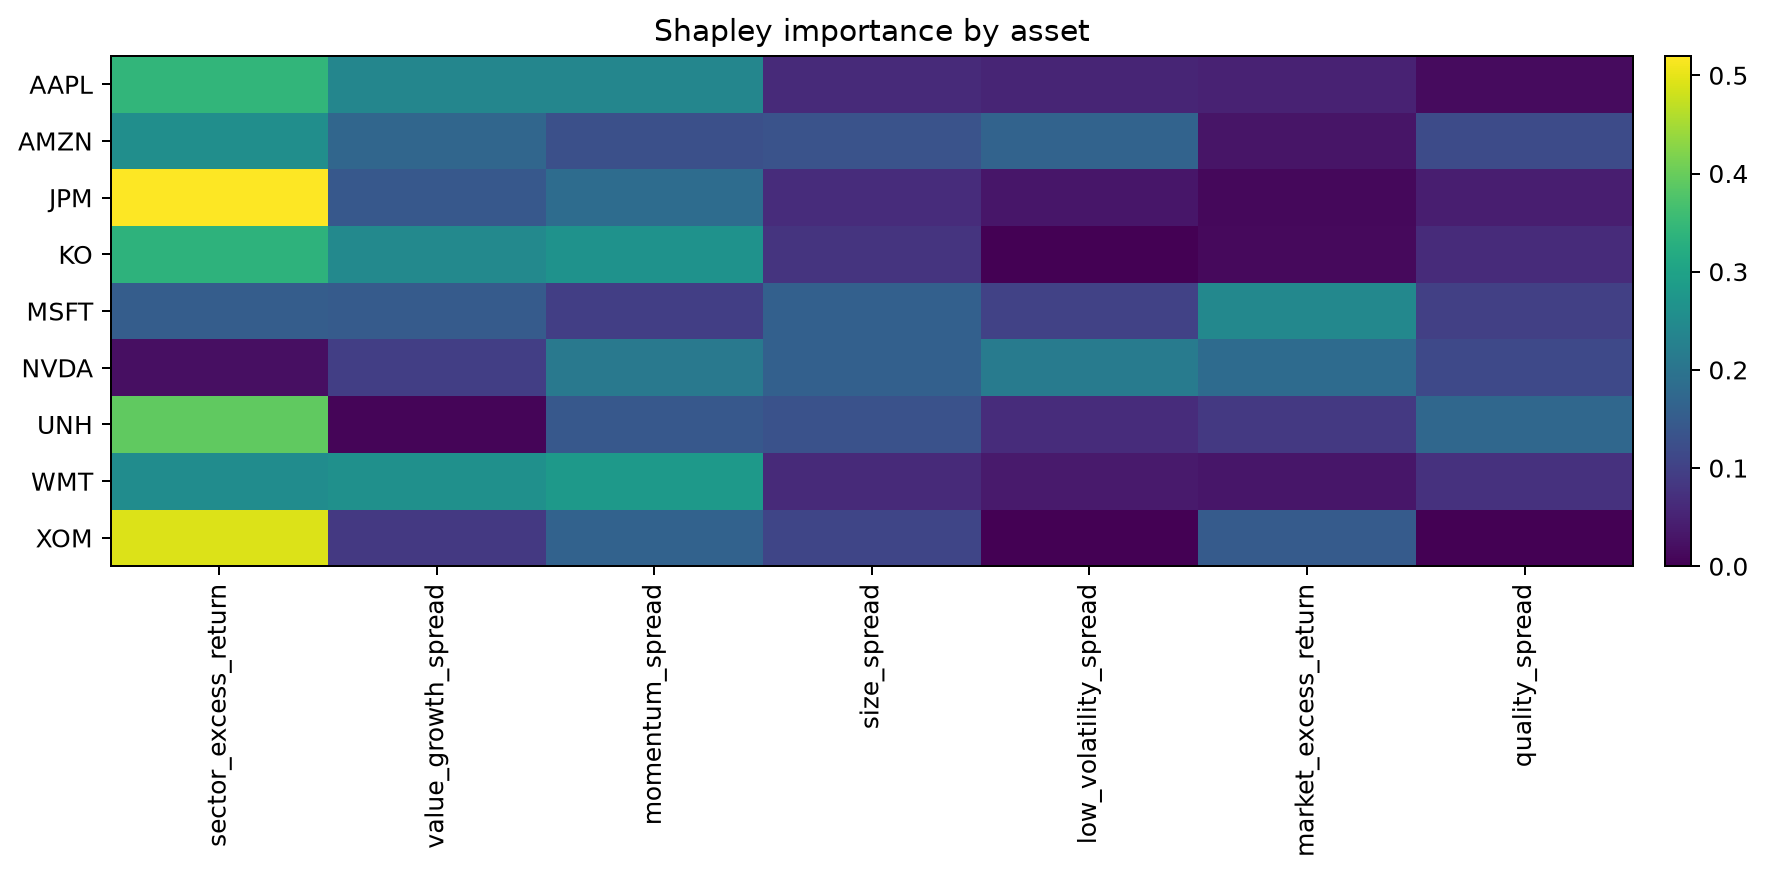

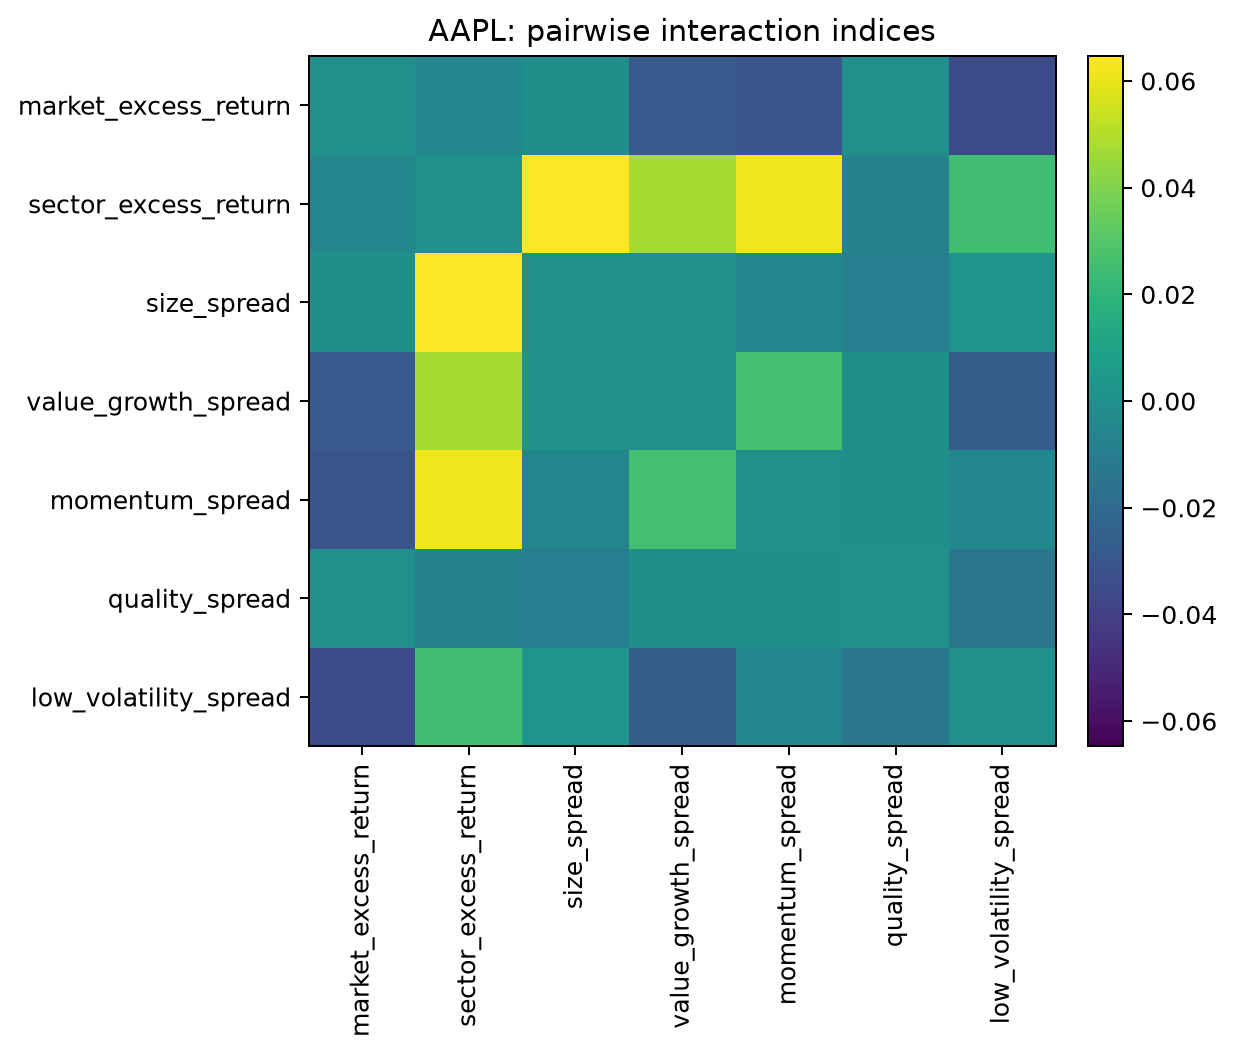

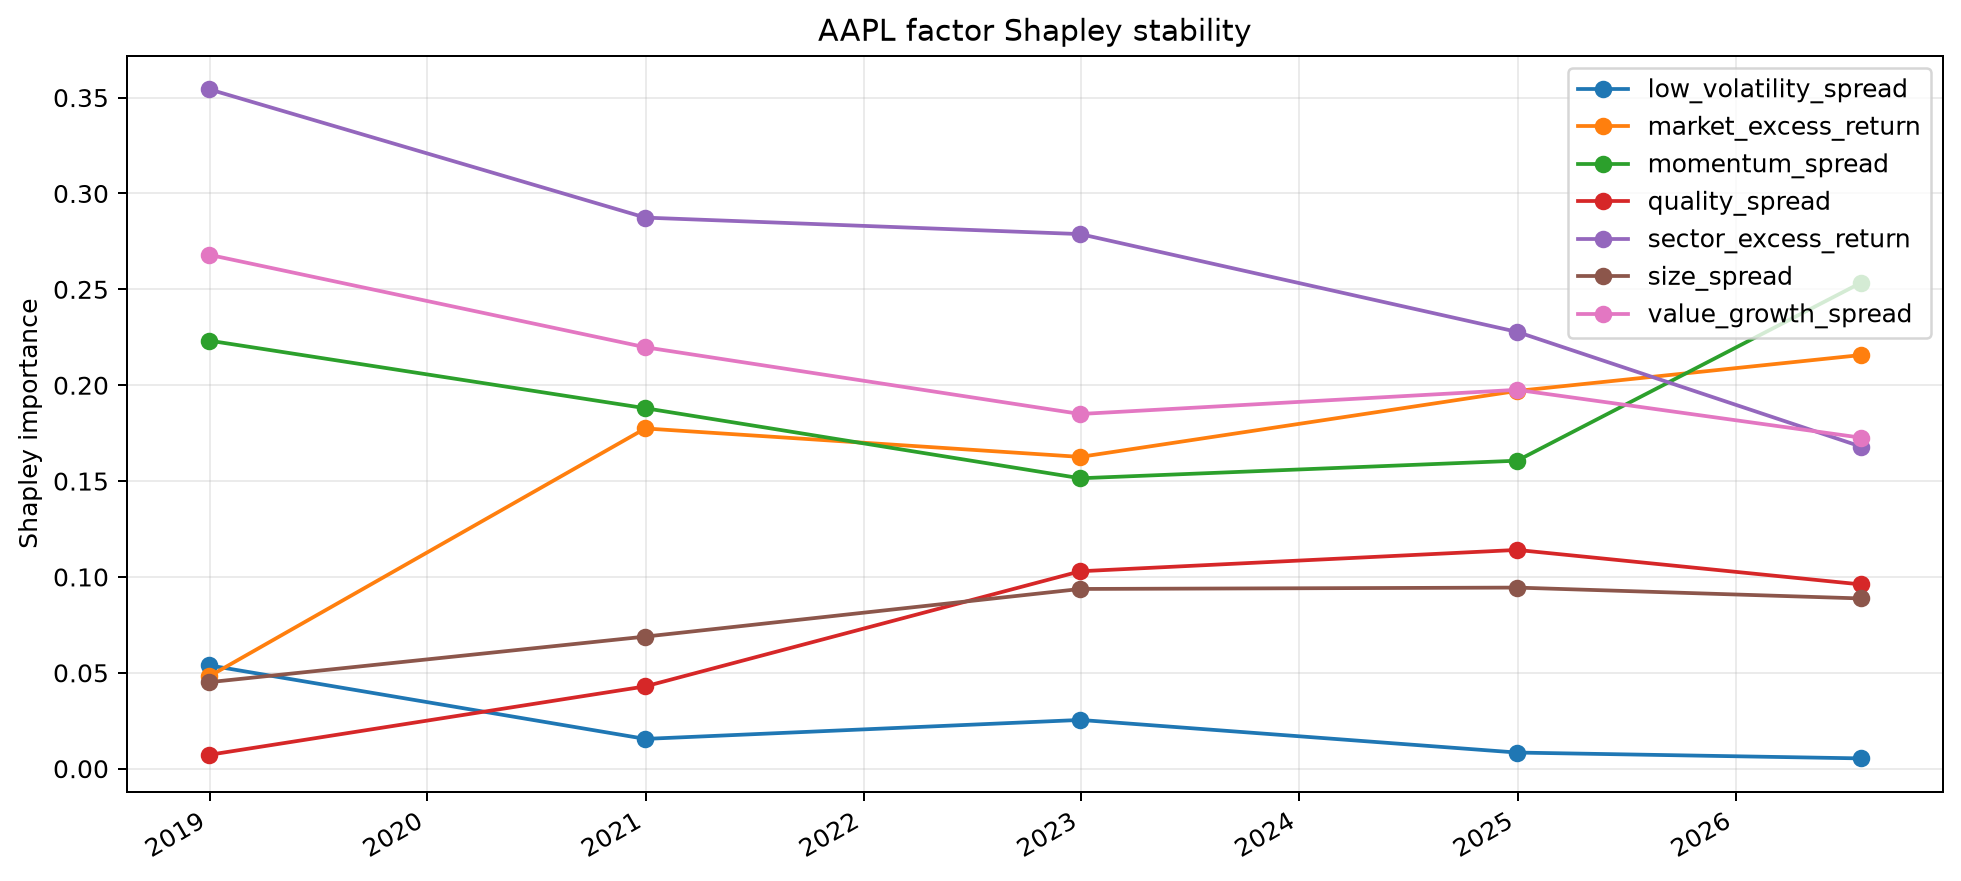

In [4]:
display(Markdown("### Normalised factor weights\nFor a 1-additive Choquet model, Shapley indices are the model's normalised non-negative linear factor weights."))
display(load_result_table("experiment_1_shapley_indices.csv", index_col=0))
display(Markdown("### Stability and inference for AAPL\nCheck whether importance estimates persist across expanding samples and whether HAC comparisons support performance differences."))
display(load_result_table("experiment_1_aapl_shapley_stability.csv", index_col=0))
display(load_result_table("experiment_1_aapl_hac_comparison.csv", index_col=0))
display(Markdown("### Factor-weight visualizations\nThe figures summarize average weights, cross-asset heterogeneity and temporal stability."))
display(Image(filename=result_figure_path("experiment_1_average_shapley.png")))
display(Image(filename=result_figure_path("experiment_1_shapley_by_asset.png")))
display(Image(filename=result_figure_path("experiment_1_aapl_shapley_stability.png")))